In [ ]:
import numpy as np

x = np.random.rand(10000)*10+80;

mean_x = np.mean(x)
variance_x = np.var(x)
standard_deviation_x = np.std(x)

print(f"Mean of x: {mean_x}")
print(f"Population Variance of x: {variance_x}")
print(f"Population Standard Deviation of x: {standard_deviation_x}")

Mean of x: 85.0048507782035
Population Variance of x: 8.41288739596176
Population Standard Deviation of x: 2.9004977841677038


In [ ]:
num_samples = 100
sample_size = 50

samples = []
for _ in range(num_samples):
    # Sample with replacement from x
    sample = np.random.choice(x, size=sample_size, replace=True)
    samples.append(sample)

print(f"Generated {len(samples)} samples, each with size {samples[0].shape[0]}")

Generated 100 samples, each with size 50


In [ ]:
sample_means = []
sample_variances = []
sample_standard_errors = []

for i, sample in enumerate(samples):
    sample_mean = np.mean(sample)
    sample_variance = np.var(sample)
    sample_std = np.std(sample) # Calculate sample standard deviation
    sample_sem = sample_std / np.sqrt(sample_size) # Calculate standard error of the mean

    sample_means.append(sample_mean)
    sample_variances.append(sample_variance)
    sample_standard_errors.append(sample_sem)

    #print(f"Sample {i+1}: Mean = {sample_mean:.4f}, Variance = {sample_variance:.4f}, Std Error = {sample_sem:.4f}")

In [ ]:
mean_of_sample_means = np.mean(sample_means)
variance_of_sample_means = np.var(sample_means)
std_dev_of_sample_means = np.std(sample_means)

print(f"Mean of sample means: {mean_of_sample_means:.4f}")
print(f"Variance of sample means: {variance_of_sample_means:.4f}")
print(f"Standard Deviation of sample means: {std_dev_of_sample_means:.4f}")

Mean of sample means: 85.0180
Variance of sample means: 0.1727
Standard Deviation of sample means: 0.4156


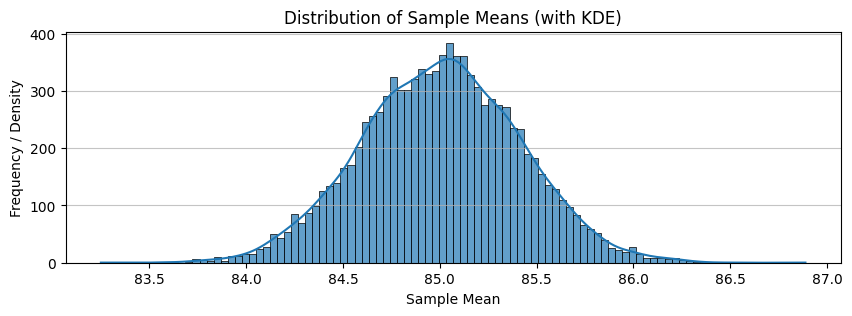

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 3)) # Increased figure height for better visibility
sns.histplot(sample_means, bins=int(num_samples/100), kde=True, edgecolor='black', alpha=0.7)
plt.title('Distribution of Sample Means (with KDE)')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency / Density')
plt.grid(axis='y', alpha=0.75)
plt.show()


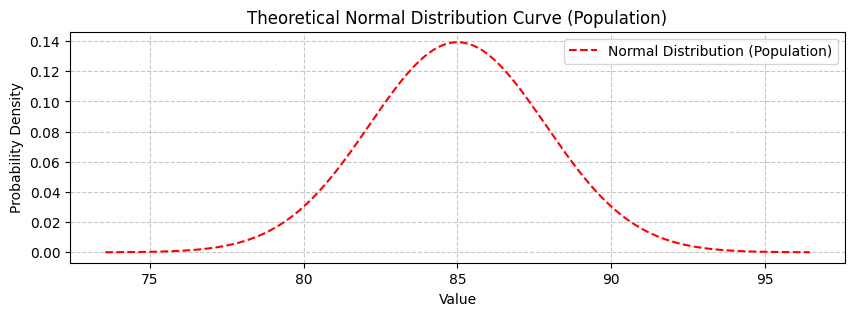

In [ ]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np

# Get population mean and standard deviation from kernel state (mean_x, standard_deviation_x)
# Assuming mean_x and standard_deviation_x are available from cell g29eZEMHgBsH

plt.figure(figsize=(10, 3))

# Generate x values for the normal distribution curve
x_values = np.linspace(mean_x - 4 * standard_deviation_x, mean_x + 4 * standard_deviation_x, 500)

# Calculate the probability density function (PDF) for a normal distribution
pdf_values = norm.pdf(x_values, loc=mean_x, scale=standard_deviation_x)

plt.plot(x_values, pdf_values, color='red', linestyle='--', label='Normal Distribution (Population)')
plt.title('Theoretical Normal Distribution Curve (Population)')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [ ]:
import pandas as pd

# Convert the list of samples (each a numpy array) into a 2D numpy array
samples_array = np.array(samples)

# Transpose the array so that each sample becomes a column
samples_transposed = samples_array.T

# Create a DataFrame from the transposed samples
# Assign column names as 'sample1', 'sample2', etc.
column_names = [f'sample{i+1}' for i in range(samples_transposed.shape[1])]
df_samples = pd.DataFrame(samples_transposed, columns=column_names)

# Save the DataFrame to a CSV file
df_samples.to_csv('all_samples_data.csv', index=False)

print("All sample data saved to 'all_samples_data.csv'")

All sample data saved to 'all_samples_data.csv'


In [ ]:
import pandas as pd
df = pd.read_csv("all_samples_data.csv")
data = df[]